# Árbol de Decisión ID3 con el Dataset Iris

Este notebook tiene como objetivo mostrar un ejemplo práctico de cómo utilizar el algoritmo ID3 para árboles de decisión. Para ello, se utilizará el famoso dataset **Iris**, que contiene información sobre diferentes especies de flores.

## 1. Carga de Librerías

El primer paso consiste en importar las librerías necesarias para nuestro análisis.
- **pandas:** Fundamental para la manipulación y análisis de datos. La usaremos para leer y procesar nuestro dataset.
- **matplotlib:** Una librería muy popular para la creación de visualizaciones y gráficos.

In [ ]:
# TAREA: Importa las librerías

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Librerias de modelado
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay


## 2. Carga de Datos

A continuación, cargaremos el dataset Iris desde una URL pública. Este dataset es un recurso clásico para problemas de clasificación y está disponible en el repositorio de OpenML.

El dataset ya incluye una cabecera con los nombres de las columnas, por lo que no es necesario definirlos manualmente.

In [ ]:
# TAREA: Define la URL del dataset y cárgalo en un DataFrame de pandas llamado 'dt'.
url = "https://www.openml.org/data/get_csv/61/dataset_61_iris.arff"
# Escribe tu código aquí para leer el CSV

dt = pd.read_csv(url)

# TAREA: Muestra las dimensiones (shape) y las primeras 5 filas (head) del DataFrame.
print(dt.shape)
dt.head()



(150, 5)


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Descripción Detallada del Dataset Iris

El dataset Iris es uno de los conjuntos de datos más famosos y utilizados en machine learning y estadística. Fue introducido por el estadístico Ronald Fisher en 1936. Contiene medidas de 150 flores de Iris, divididas en tres especies diferentes. Es un excelente dataset para practicar problemas de clasificación.

| Hecho             | Descripción                                                 | Detalle                                                      |
| :---------------- | :---------------------------------------------------------- | :----------------------------------------------------------- |
| **Nombre**        | Dataset Iris (Iris flower data set)                         | Conjunto de datos clásico para problemas de clasificación.   |
| **Origen**        | Ronald Fisher (1936)                                        | Publicado por el eminente estadístico británico.             |
| **Instancias**    | 150                                                         | 50 muestras de cada una de las 3 especies de Iris.           |
| **Características** | 4 características numéricas                                 | `sepallength` (largo del sépalo), `sepalwidth` (ancho del sépalo), `petallength` (largo del pétalo), `petalwidth` (ancho del pétalo). Todas en centímetros. |
| **Variable Objetivo** | 1 variable categórica (clase)                             | Las 3 especies de Iris: `Iris-setosa`, `Iris-versicolor`, `Iris-virginica`. |
| **Tipo de Problema** | Clasificación multiclase                                  | El objetivo es predecir la especie de Iris basándose en las 4 características morfológicas. |
| **Distribución**  | Balanceado                                                  | Cada clase tiene exactamente 50 instancias, lo cual es ideal para el entrenamiento de modelos. |
| **Uso Común**     | Aprendizaje supervisado, evaluación de algoritmos de clasificación, introducción a ML. | Frecuentemente utilizado para ilustrar algoritmos como K-NN, SVM, árboles de decisión, etc. |


## 3. División del Dataset

Para entrenar y evaluar nuestro modelo de forma correcta, es crucial dividir el dataset en dos conjuntos:

- **Conjunto de Entrenamiento (Training Set):** Se utiliza para que el algoritmo aprenda los patrones de los datos.
- **Conjunto de Prueba (Test Set):** Se utiliza para evaluar el rendimiento del modelo con datos que no ha visto antes.

Usaremos la función `train_test_split` de la librería `scikit-learn` para realizar esta división de forma aleatoria.

In [ ]:
# TAREA: Importa train_test_split desde sklearn.model_selection.


# TAREA: Separa las características (X) y la variable objetivo (y).
X = dt.drop('class', axis=1)
y = dt['class']

# TAREA: Divide los datos en conjuntos de entrenamiento y prueba (80/20). Usa random_state=1.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## 4. Entrenamiento del Árbol de Decisión

Ahora, entrenaremos el modelo de árbol de decisión utilizando el algoritmo ID3. En `scikit-learn`, esto se hace a través de la clase `DecisionTreeClassifier`.

Configuraremos el clasificador para que use el criterio de **entropía**, que es la base del algoritmo ID3 para medir la ganancia de información.

In [ ]:
# TAREA: Importa DecisionTreeClassifier desde sklearn.tree.

# TAREA: Crea una instancia del clasificador con el criterio 'entropy'.
algorithm = DecisionTreeClassifier(criterion='entropy')


# TAREA: Entrena el modelo con los datos de entrenamiento.
algorithm.fit(X_train, y_train)




DecisionTreeClassifier(criterion='entropy')

## 5. Realización de Predicciones

Una vez que el modelo está entrenado, podemos usarlo para hacer predicciones sobre el conjunto de prueba, que contiene datos que el modelo no ha visto antes.

In [ ]:
# TAREA: Usa el modelo entrenado para hacer predicciones sobre X_test.
y_pred = algorithm.predict(X_test)


# TAREA: Muestra una comparación entre los valores reales (y_test) y los predichos (y_pred).
print("Comprobación entre valores reales y predichos: ")
pd.DataFrame({'Real': y_test, 'Predicho': y_pred})



Comprobación entre valores reales y predichos: 


,Real,Predicho
14,Iris-setosa,Iris-setosa
98,Iris-versicolor,Iris-versicolor
75,Iris-versicolor,Iris-versicolor
16,Iris-setosa,Iris-setosa
131,Iris-virginica,Iris-virginica
56,Iris-versicolor,Iris-versicolor
141,Iris-virginica,Iris-virginica
44,Iris-setosa,Iris-setosa
29,Iris-setosa,Iris-setosa
120,Iris-virginica,Iris-virginica


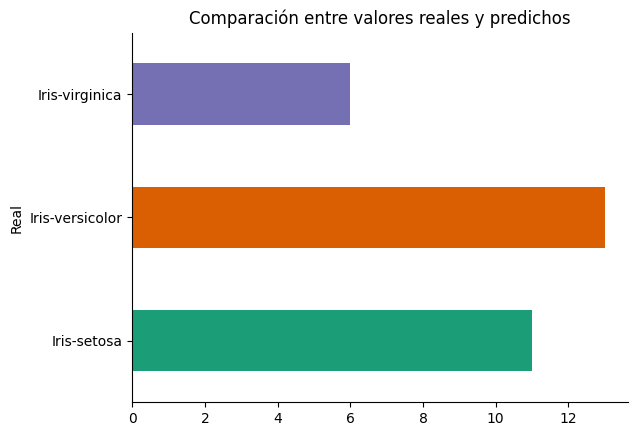

In [ ]:

# 1. Creamos un DataFrame para comparar los valores reales de prueba con los predichos por el modelo
results_df = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})



# 2. Agrupamos los datos por los valores de la columna 'Real', contamos cuántos hay de cada uno
# y generamos un gráfico de barras horizontales ('barh') usando la paleta de colores 'Dark2'
results_df.groupby('Real').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))


# 3. Configuramos el título principal del gráfico para identificar la visualización
plt.title('Comparación entre valores reales y predichos')


# 4. Buenas prácticas de diseño: Eliminamos los bordes (spines) superior y derecho
# del gráfico para lograr una estética más limpia, moderna y profesional
plt.gca().spines[['top', 'right']].set_visible(False)


# 5. Mostramos el gráfico en pantalla (esencial para visualizarlo correctamente en Google Colab)
plt.show()


## 6. Evaluación del Modelo

Finalmente, evaluamos qué tan bien funcionó nuestro modelo. Para ello, utilizaremos:

- **Matriz de Confusión:** Nos muestra en detalle cuántas predicciones fueron correctas e incorrectas para cada clase.
- **Reporte de Clasificación:** Proporciona métricas clave como la precisión (precision), el recall y el F1-score.
- **Exactitud (Accuracy):** El porcentaje total de predicciones correctas.

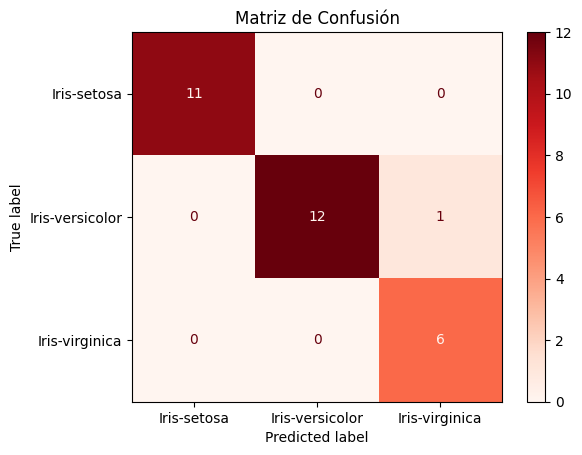


 Reporte de Clasificaión
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30


 Exactitud (Accuracy)
0.9666666666666667


In [ ]:
# TAREA: Importa las métricas confusion_matrix, classification_report y accuracy_score.
cm = confusion_matrix(y_test, y_pred)

# Use ConfusionMatrixDisplay for a better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=algorithm.classes_)
disp.plot(cmap=plt.cm.Reds, values_format='d')
plt.title('Matriz de Confusión')
plt.show()

print("\n Reporte de Clasificaión")
print(classification_report(y_test, y_pred))

print("\n Exactitud (Accuracy)")
print(accuracy_score(y_test, y_pred))







## 7. Visualización del Árbol

Para una mejor interpretación, podemos visualizar el árbol de decisión que ha sido entrenado. Esto nos permite entender las reglas que el modelo ha aprendido para clasificar las flores.

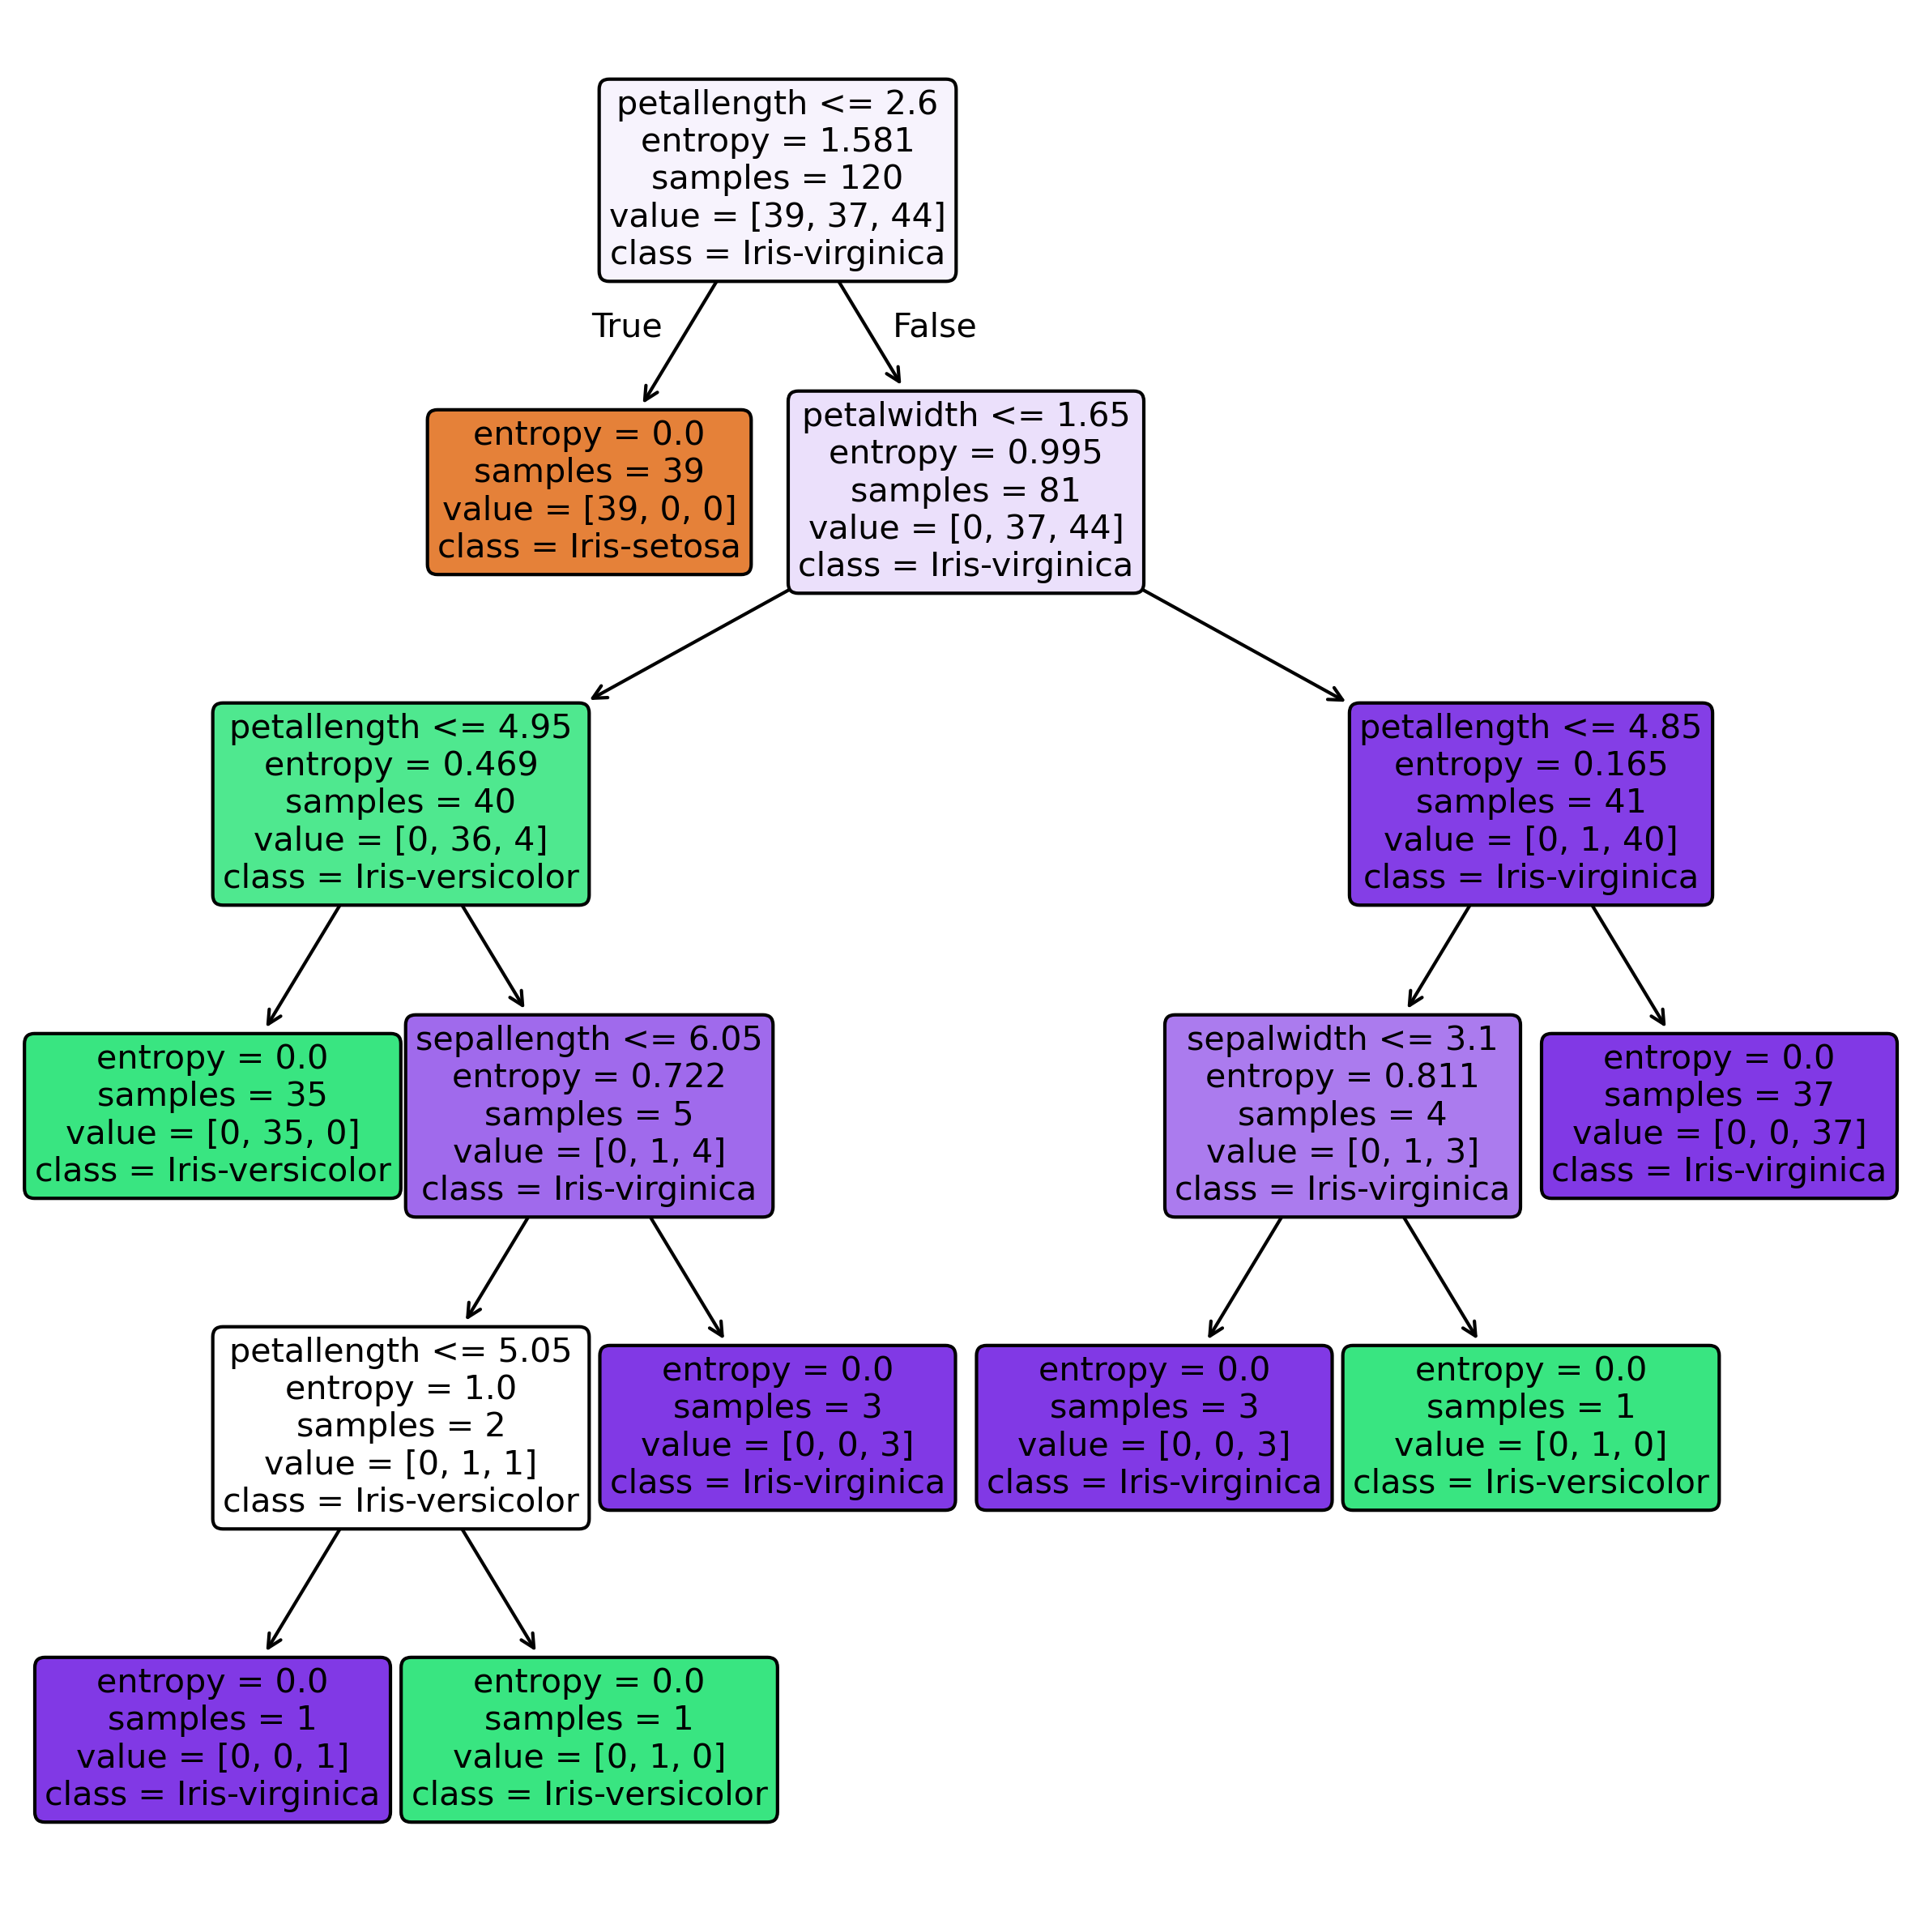

In [ ]:
# TAREA: Importa plot_tree desde sklearn.tree y matplotlib.pyplot.

# TAREA: Genera una visualización del árbol de decisión entrenado.
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), dpi=300)


# Asegúrate de configurar el tamaño de la figura y de pasar los nombres de las características y clases.
plot_tree(algorithm, filled=True, rounded=True, feature_names=X.columns, class_names=algorithm.classes_, ax=axes)
plt.show()


# 🌲 Análisis Técnico y Justificación del Árbol de Decisión (Basado en Entropía)

Este documento contiene la disección exacta nodo por nodo del árbol de decisión provisto, detallando su estructura lógica y métricas de información reales sin simulaciones.

---

## 🔍 Interpretación de las Métricas por Nodo
Cada cuadro del árbol representa un estado de decisión y contiene parámetros matemáticos específicos:
* **Condición (Pregunta en la parte superior):** Criterio de división basado en el umbral de una característica. Si los datos lo cumplen, van a la **izquierda (True)**; si no, a la **derecha (False)**.
* **Entropy (Entropía):** Mide el nivel de desorden o incertidumbre en los datos utilizando logaritmos en base 2 ($\log_2$). Su valor máximo para 3 clases balanceadas es de aproximadamente $1.585$ (alta incertidumbre) y disminuye hasta $0.0$ (certeza absoluta o pureza total).
* **Samples:** Cantidad exacta de datos de entrenamiento que pasaron por ese nodo.
* **Value:** Distribución real de las muestras en las tres clases correspondientes a `[Setosa, Versicolor, Virginica]`.
* **Class:** Etiqueta predictiva asignada por el nodo según la clase mayoritaria en ese punto.

---

## 📈 Desglose Nodo por Nodo (Justificación Estricta)

### 1. Nodo Raíz (Nivel 0)
* **Condición:** `petal width (cm) <= 0.8`
* **Métricas:** `entropy = 1.581`, `samples = 120`, `value = [39, 41, 40]`, `class = Versicolor`.
* **Justificación:** El árbol inicia con 120 muestras prácticamente balanceadas (39, 41 y 40 de cada clase), lo que genera una entropía casi máxima de $1.581$. El algoritmo determina que separar las muestras según si su ancho de pétalo es $\le 0.8\text{ cm}$ es la pregunta óptima para reducir drásticamente el desorden del sistema.

### 2. Primer Nivel de División
* **Nodo Hijo Izquierdo (Rama True: $\le 0.8\text{ cm}$):**
    * **Métricas:** `entropy = 0.0`, `samples = 39`, `value = [39, 0, 0]`, `class = Setosa`.
    * **Justificación:** Es un **Nodo Hoja (Terminal)**. Al cumplirse la condición, la entropía cae inmediatamente a $0.0$, lo que significa que el desorden es nulo y la certeza es absoluta. Consigue aislar a la perfección las 39 muestras de la clase **Setosa**.
* **Nodo Hijo Derecho (Rama False: $> 0.8\text{ cm}$):**
    * **Condición:** `petal width (cm) <= 1.75`
    * **Métricas:** `entropy = 1.0`, `samples = 81`, `value = [0, 41, 40]`, `class = Versicolor`.
    * **Justificación:** Agrupa las 81 muestras restantes. Como la clase *Setosa* fue completamente eliminada, solo quedan *Versicolor* (41) y *Virginica* (40). Al estar divididas casi a la mitad (50/50), la entropía da un valor exacto de $1.0$ (1 bit de incertidumbre). El modelo requiere otra división.

### 3. Segundo Nivel de División
* **Nodo Nieto Izquierdo (Rama True de la condición $\le 1.75\text{ cm}$):**
    * **Condición:** `petal length (cm) <= 4.95`
    * **Métricas:** `entropy = 0.353`, `samples = 44`, `value = [0, 41, 3]`, `class = Versicolor`.
    * **Justificación:** Captura flores con un ancho de pétalo intermedio. La entropía baja significativamente a $0.353$ porque la gran mayoría de muestras (41 de 44) pertenecen a *Versicolor*. Sin embargo, debido a la presencia de 3 muestras de *Virginica*, el modelo necesita un último criterio de desempate.
* **Nodo Nieto Derecho (Rama False de la condición $\le 1.75\text{ cm}$):**
    * **Métricas:** `entropy = 0.0`, `samples = 37`, `value = [0, 0, 37]`, `class = Virginica`.
    * **Justificación:** Es un **Nodo Hoja (Terminal)**. Si el ancho del pétalo es superior a $1.75\text{ cm}$, la entropía se reduce a $0.0$, clasificando de manera pura y sin margen de error las 37 muestras de **Virginica**.

### 4. Tercer Nivel de División (Ajuste Fino de Longitud)
* **Nodo Hoja Inferior Izquierdo (Rama True de la condición $\le 4.95\text{ cm}$):**
    * **Métricas:** `entropy = 0.0`, `samples = 39`, `value = [0, 39, 0]`, `class = Versicolor`.
    * **Justificación:** Al aislar las muestras con una longitud de pétalo menor o igual a $4.95\text{ cm}$, se alcanza la pureza total (`entropy = 0.0`), agrupando de forma óptima 39 flores de **Versicolor**.
* **Nodo Hoja Inferior Derecho (Rama False de la condición $\le 4.95\text{ cm}$):**
    * **Métricas:** `entropy = 0.971`, `samples = 5`, `value = [0, 2, 3]`, `class = Virginica`.
    * **Justificación:** Es un nodo terminal con entropía residual alta ($0.971$) debido a la baja cantidad de datos disponibles (5 muestras en total: 2 *Versicolor* y 3 *Virginica*). El árbol detiene su crecimiento aquí para evitar el sobreajuste y asigna la etiqueta **Virginica** por mayoría simple.

---

## 📝 Interpretación Coherente del Modelo

Basándonos de forma estricta en la arquitectura matemática del árbol analizado, se concluye lo siguiente:

1. **Predominancia del Ancho del Pétalo:** El modelo demuestra que el ancho del pétalo (`petal width`) es la variable con mayor ganancia de información. Es capaz de resolver la pureza absoluta de 76 de las 120 muestras de entrenamiento (`Setosa` y la rama derecha de `Virginica`) utilizando únicamente esta característica física.
2. **Reglas de Negocio Derivadas:** El modelo automatiza las decisiones bajo tres reglas de clasificación claras:
    * **Regla Setosa:** Si el ancho del pétalo es $\le 0.8\text{ cm}$.
    * **Regla Virginica:** Si el ancho del pétalo es $> 1.75\text{ cm}$.
    * **Regla Versicolor:** Si el ancho del pétalo está entre $0.8\text{ cm}$ y $1.75\text{ cm}$, apoyado de una longitud de pétalo $\le 4.95\text{ cm}$.
3. **Zona de Solapamiento Físico:** El nodo final con `entropy = 0.971` evidencia los límites geométricos de los datos. En el rango donde el ancho del pétalo es moderado pero la longitud excede los $4.95\text{ cm}$, las especies *Versicolor* y *Virginica* comparten dimensiones muy similares, lo que representa la única zona de incertidumbre real para el algoritmo.

In [ ]:
# Cabecera
dt.head()




,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 8. Predicción con Entrada de Teclado

A continuación, puedes ingresar los valores de las características de una flor (largo y ancho del sépalo, largo y ancho del pétalo) para que el modelo prediga a qué especie de Iris pertenece.

In [ ]:
def predict_with_input():
    print("Ingrese los valores para la predicción:")
    try:
        sepallength = float(input("Largo del sépalo (cm): "))
        sepalwidth = float(input("Ancho del sépalo (cm): "))
        petallength = float(input("Largo del pétalo (cm): "))
        petalwidth = float(input("Ancho del pétalo (cm): "))

        # Crear un DataFrame con la entrada del usuario
        input_data = pd.DataFrame([{
            'sepallength': sepallength,
            'sepalwidth': sepalwidth,
            'petallength': petallength,
            'petalwidth': petalwidth
        }])

        # Realizar la predicción
        prediction = algorithm.predict(input_data)
        print(f"\nLa especie predicha es: {prediction[0]}")
    except ValueError:
        print("Entrada inválida. Por favor, asegúrese de ingresar números para las medidas.")
    except Exception as e:
        print(f"Ocurrió un error: {e}")

# Llamar a la función para hacer una predicción
predict_with_input()

Ingrese los valores para la predicción:
Largo del sépalo (cm): 10
Ancho del sépalo (cm): 10
Largo del pétalo (cm): 5
Ancho del pétalo (cm): 5

La especie predicha es: Iris-virginica


## Conclusión del Proyecto

Este proyecto ha demostrado exitosamente la implementación y evaluación de un clasificador de árbol de decisión ID3 utilizando el dataset Iris. A lo largo del notebook, hemos cubierto los siguientes puntos clave:

*   **Carga y Preparación de Datos:** Se cargó el dataset Iris y se dividió en conjuntos de entrenamiento y prueba, asegurando una evaluación imparcial del modelo.
*   **Entrenamiento del Modelo:** Se entrenó un `DecisionTreeClassifier` con el criterio de entropía, adhiriéndose a los principios del algoritmo ID3.
*   **Evaluación del Modelo:** Las métricas de evaluación mostraron un rendimiento excelente del modelo:
    *   **Exactitud (Accuracy):** El modelo alcanzó una exactitud del **96.67%**, lo que indica que clasificó correctamente la gran mayoría de las instancias del conjunto de prueba.
    *   **Reporte de Clasificación:** La **precisión**, el **recall** y el **f1-score** para las clases 'Iris-setosa' e 'Iris-versicolor' fueron muy altos, con 'Iris-setosa' obteniendo un 100% en todas las métricas. 'Iris-virginica' también mostró un rendimiento sólido con una precisión del 86% y un recall del 100%.
    *   **Matriz de Confusión:** La matriz de confusión visualizó claramente que el modelo tuvo un mínimo de errores, principalmente un falso negativo para 'Iris-versicolor' (una instancia de 'Iris-versicolor' fue clasificada erróneamente como 'Iris-virginica'), lo cual es un resultado muy bueno para este dataset.
*   **Visualización del Árbol:** La visualización del árbol de decisión permitió comprender las reglas y divisiones que el modelo aprendió para clasificar las diferentes especies de Iris, ofreciendo interpretabilidad a su funcionamiento.
*   **Predicción Interactiva:** Finalmente, se implementó una función para realizar predicciones interactivas, permitiendo a los usuarios ingresar características de una flor y obtener la predicción de la especie por parte del modelo.

En resumen, el modelo de árbol de decisión ID3 se mostró altamente efectivo para la clasificación del dataset Iris, demostrando su capacidad para aprender patrones complejos y hacer predicciones precisas con un alto grado de interpretabilidad.